<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# K-Means Clustering

The `01_Supervised_Learning` folder was about data that comes with the answers
attached: every taxi ride had a fare, every applicant had an admission decision. The
model's job was to reproduce those answers on rides and applicants it had not seen.

**Unsupervised learning** is what you do when there are no answers. Nobody has
labelled anything, and the algorithm has to find structure in the data on its own.

The most common form of that is **clustering**: given a pile of measurements,
which of them belong together? This notebook works through **k-means**, the classic
clustering algorithm.

---

## Contents

1. [The data](#data)
2. [Looking at the data](#look)
3. [What k-means does](#kmeans)
4. [Two clusters](#k2)
5. [Three clusters](#k3)
6. [Putting the features on the same scale](#scaling)
7. [Comparing with the truth](#truth)

<a id="data"></a>
## 1. The data

We use the **Palmer penguins**: size measurements for 344 adult penguins of three
species — Adélie, Chinstrap and Gentoo — collected at the Palmer Station in
Antarctica.

| Column | Meaning |
|---|---|
| **species** | Adelie, Chinstrap or Gentoo |
| **island** | Which island the penguin was found on |
| **bill_length_mm** | Length of the bill, in millimetres |
| **bill_depth_mm** | Depth of the bill, in millimetres |
| **flipper_length_mm** | Length of the flipper, in millimetres |
| **body_mass_g** | Body mass, in grams |
| **sex** | female or male |
| **year** | Year of the observation |

*Data collected by Dr. Kristen Gorman and the Palmer Station Antarctica LTER, and
made available through the
[palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) package.*

The data ships inside that package, so there is no file to read — `load_penguins()`
hands back a ready-made DataFrame.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins

penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


This dataset has something the taxi data did not: **it already contains the
answer.** The `species` column tells us exactly which group each penguin belongs to.

We are going to *hide* it. The clustering algorithm gets two measurements and
nothing else, and afterwards we compare what it found against the species column —
which makes this an unusually honest way to see whether clustering works at all.

Two of the measurements are enough, and they keep everything drawable on a flat
page. Two penguins are missing measurements, so we drop them once, from both columns
together, and keep the species alongside for later.

In [2]:
data = penguins[["bill_length_mm", "flipper_length_mm", "species"]].dropna()
X = data[["bill_length_mm", "flipper_length_mm"]]

print("penguins in the file: ", len(penguins))
print("penguins we can use:  ", len(data))

penguins in the file:  344
penguins we can use:   342


<a id="look"></a>
## 2. Looking at the data

Before any algorithm, plot it. This is what k-means will be given — two numbers per
penguin, no labels.

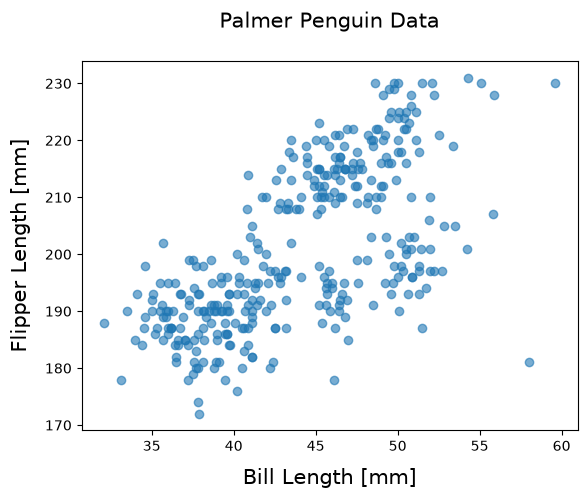

In [3]:
plt.scatter(X["bill_length_mm"], X["flipper_length_mm"], alpha=0.6)

plt.title("Palmer Penguin Data\n", fontsize=15)
plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)
plt.show()

Even without labels the eye picks out structure: a dense group at the bottom left,
another towards the top right, and something in between.

And because this dataset *does* carry the answer, we can look at what those groups
really are. Colouring the same points by species — information the algorithm will
never receive — shows what a perfect clustering would look like.

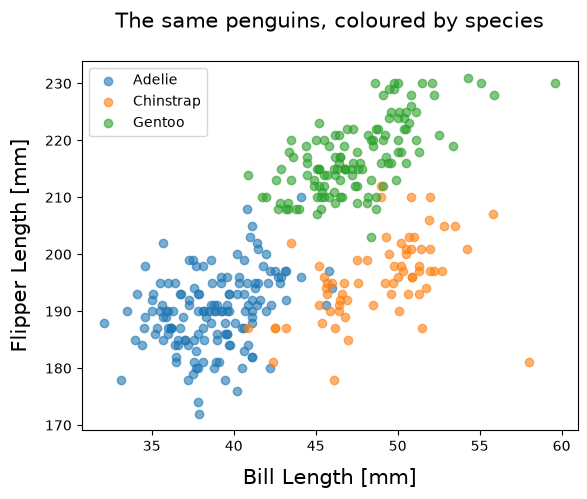

In [4]:
for species, group in data.groupby("species"):
    plt.scatter(group["bill_length_mm"], group["flipper_length_mm"],
                alpha=0.6, label=species)

plt.title("The same penguins, coloured by species\n", fontsize=15)
plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)
plt.legend()
plt.show()

Three species, and they occupy three fairly distinct regions — though Adélie and
Chinstrap overlap noticeably. Keep this picture in mind; it is the target.

<a id="kmeans"></a>
## 3. What k-means does

K-means needs one thing from you: **k**, how many clusters to look for. It cannot
work that out itself.

Given k, it repeats two steps until nothing changes:

1. **Assign** — every point joins the cluster whose centre is nearest to it
2. **Move** — every centre moves to the *mean* position of the points that just
   joined it

That second step is where the name comes from: each cluster is represented by the
mean of its members. The centres start somewhere sensible (`init="k-means++"`
spreads them out rather than placing them at random), and because the starting
position still affects the outcome, `n_init=10` runs the whole thing ten times and
keeps the best result.

<a id="k2"></a>
## 4. Two clusters

Start with the simplest question: split the penguins into **two** groups.

In [5]:
from sklearn.cluster import KMeans

k_means = KMeans(init="k-means++", n_clusters=2, n_init=10, random_state=0)
k_means.fit(X)

k_means.cluster_centers_.round(1)

array([[ 47.8, 215.9],
       [ 41.3, 190.6]])

Those two coordinate pairs are the whole model — the centre of each cluster.
`labels_` says which cluster each penguin ended up in.

Plotting the points coloured by cluster, with the centres marked:

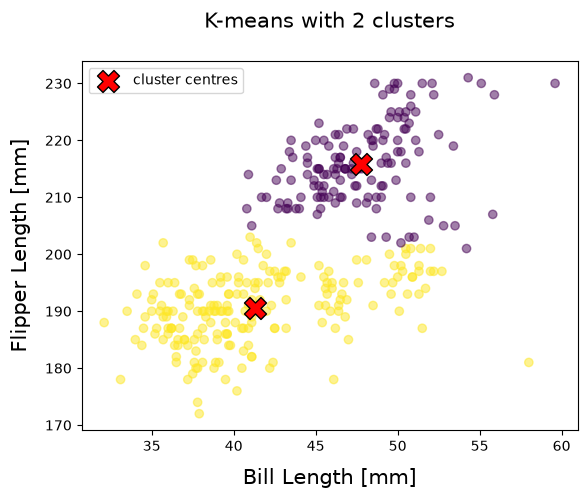

In [6]:
plt.scatter(X["bill_length_mm"], X["flipper_length_mm"], c=k_means.labels_, alpha=0.5)
plt.scatter(k_means.cluster_centers_[:, 0], k_means.cluster_centers_[:, 1],
            c="red", s=250, marker="X", edgecolors="black", label="cluster centres")

plt.title("K-means with 2 clusters\n", fontsize=15)
plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)
plt.legend()
plt.show()

A clean split, and comparing it with the species plot above, the upper group is
essentially the Gentoo penguins. But we know there are **three** species, and this
has merged two of them.

<a id="k3"></a>
## 5. Three clusters

The obvious fix is to ask for three.

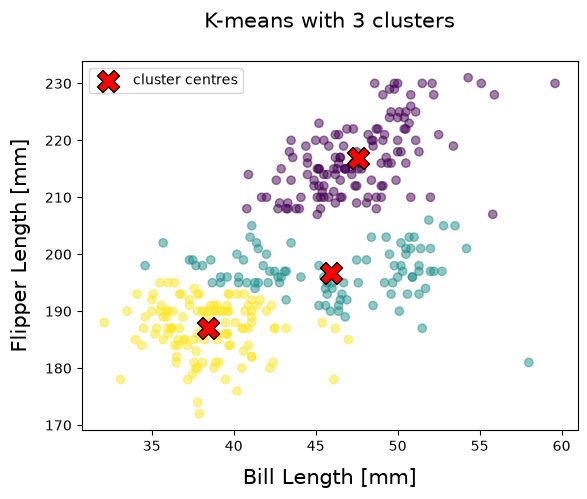

In [7]:
k_means_3 = KMeans(init="k-means++", n_clusters=3, n_init=10, random_state=0)
k_means_3.fit(X)

plt.scatter(X["bill_length_mm"], X["flipper_length_mm"], c=k_means_3.labels_, alpha=0.5)
plt.scatter(k_means_3.cluster_centers_[:, 0], k_means_3.cluster_centers_[:, 1],
            c="red", s=250, marker="X", edgecolors="black", label="cluster centres")

plt.title("K-means with 3 clusters\n", fontsize=15)
plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)
plt.legend()
plt.show()

Compare that against the species plot in [section 2](#look). It is **worse**. The
boundaries run roughly horizontally, cutting the data into three flipper-length
bands, and the Adélie/Chinstrap distinction — which is mostly a matter of bill
length — has been ignored.

We can put a number on it. `crosstab` counts how many penguins of each species
landed in each cluster.

In [8]:
comparison = pd.crosstab(data["species"], k_means_3.labels_)
comparison

col_0,0,1,2
species,,,
Adelie,2,38,111
Chinstrap,5,54,9
Gentoo,122,1,0


In [9]:
def agreement(crosstab, n):
    # label every cluster by its most common species, then count the matches
    return crosstab.max(axis=0).sum() / n

print(f"agreement with the true species: {agreement(comparison, len(data)):.1%}")

agreement with the true species: 83.9%


<a id="scaling"></a>
## 6. Putting the features on the same scale

Why did asking for the *right* number of clusters make things worse?

Because of how k-means measures "nearest". It uses ordinary straight-line distance,
and our two columns are not on comparable scales.

In [10]:
X.describe().loc[["min", "max", "std"]].round(1)

,bill_length_mm,flipper_length_mm
min,32.1,172.0
max,59.6,231.0
std,5.5,14.1


Flipper length spans about 60 mm; bill length about 27 mm. A millimetre of flipper
therefore counts for just as much as a millimetre of bill in the distance
calculation, even though flipper length varies more than twice as widely. The result
is that flipper length dominates, and the clusters come out as horizontal bands.

This is the same problem — and the same fix — as in the classification notebook of
the Deep Learning chapter: **standardise** every column to a mean of 0 and a
standard deviation of 1, so that neither can dominate by virtue of its unit.

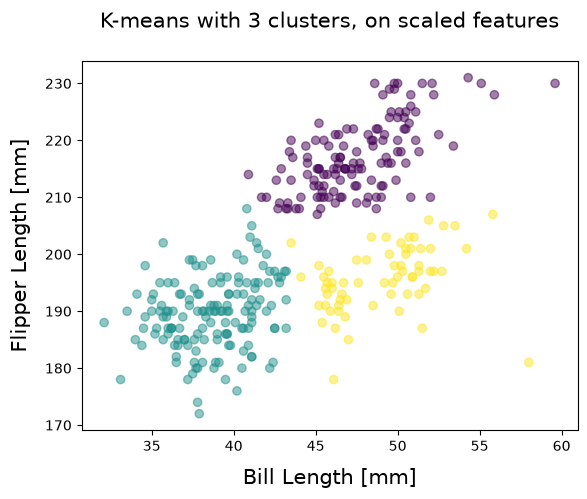

In [11]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

k_means_scaled = KMeans(init="k-means++", n_clusters=3, n_init=10, random_state=0)
k_means_scaled.fit(X_scaled)

plt.scatter(X["bill_length_mm"], X["flipper_length_mm"],
            c=k_means_scaled.labels_, alpha=0.5)

plt.title("K-means with 3 clusters, on scaled features\n", fontsize=15)
plt.xlabel("Bill Length [mm]", labelpad=10, fontsize=15)
plt.ylabel("Flipper Length [mm]", labelpad=10, fontsize=15)
plt.show()

That is a completely different — and far better — result, from exactly the same
algorithm on exactly the same measurements. Only the units changed.

Note that the points are plotted at their original millimetre positions; only the
clustering was done on the scaled values. The centres are not drawn here, because
they live in scaled coordinates and would land in the wrong place on this axis.

<a id="truth"></a>
## 7. Comparing with the truth

Now the comparison the species column was kept for.

In [12]:
comparison_scaled = pd.crosstab(data["species"], k_means_scaled.labels_)
comparison_scaled

col_0,0,1,2
species,,,
Adelie,1,146,4
Chinstrap,4,5,59
Gentoo,122,0,1


In [13]:
print(f"3 clusters, raw features:    {agreement(comparison, len(data)):.1%}")
print(f"3 clusters, scaled features: {agreement(comparison_scaled, len(data)):.1%}")

3 clusters, raw features:    83.9%
3 clusters, scaled features: 95.6%


Each cluster is now dominated by a single species, and the mistakes sit where the
species plot said they would: between Adélie and Chinstrap, which genuinely overlap.

Two things are worth taking away.

**The algorithm never saw the species column.** It was given two measurements and a
number, and recovered biological species almost exactly. That is what clustering is
for — finding groups that are really there without being told they exist.

**Preparation mattered more than the algorithm.** The difference between the two
runs above was not a better method or a better k, but putting two columns on a
common scale.